<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving production (2).csv to production (2).csv
Saving balance.csv to balance.csv
Saving prices.csv to prices.csv
Saving search.csv to search.csv
Saving weather.csv to weather.csv


In [25]:


import pandas as pd
import numpy as np


from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error


DATA = "/content/"

prod_raw = pd.read_csv(DATA + "production (2).csv")
prod = prod_raw[prod_raw["Year"].between(2000, 2024)]
prod_pivot = prod.pivot_table(index="Year", columns="Element", values="Value", aggfunc="sum")
prod_pivot.columns = [c.strip().replace(" ", "_").lower() for c in prod_pivot.columns]


bal_raw = pd.read_csv(DATA + "balance.csv")
bal = bal_raw[bal_raw["Year"].between(2000, 2024)]
bal_pivot = bal.pivot_table(index="Year", columns="Element", values="Value", aggfunc="sum")
bal_pivot.columns = ["export_qty", "import_qty"]


prices_raw = pd.read_csv(DATA + "prices.csv")
prices_yr = (
    prices_raw[prices_raw["Year"].between(2000, 2024)]
    .groupby("Year")["Value"]
    .mean()
    .rename("producer_price")
)


search_raw = pd.read_csv(DATA + "search.csv")
search_raw["Time"] = pd.to_datetime(search_raw["Time"])
search_raw["Year"] = search_raw["Time"].dt.year
search_yr = (
    search_raw[search_raw["Year"].between(2000, 2024)]
    .groupby("Year")["تمر"]
    .mean()
    .rename("search_index")
)


weather_raw = pd.read_csv(DATA + "weather.csv", skiprows=2)
weather_raw.columns = ["date", "temp_max", "temp_min", "precip"]
weather_raw["date"] = pd.to_datetime(weather_raw["date"], errors="coerce")
weather_raw = weather_raw.dropna(subset=["date"])
weather_raw["Year"] = weather_raw["date"].dt.year

weather_raw[["temp_max", "temp_min", "precip"]] = (
    weather_raw[["temp_max", "temp_min", "precip"]]
    .apply(pd.to_numeric, errors="coerce")
)

weather_yr = (
    weather_raw[weather_raw["Year"].between(2000, 2024)]
    .groupby("Year")
    .agg(
        avg_temp_max=("temp_max", "mean"),
        avg_temp_min=("temp_min", "mean"),
        total_precip=("precip", "sum"),
        precip_days=("precip", lambda x: (x > 0).sum()),
    )
    .round(2)
)


master = (
    prod_pivot
    .join(bal_pivot, how="left")
    .join(prices_yr, how="left")
    .join(search_yr, how="left")
    .join(weather_yr, how="left")
)

master.index.name = "Year"
master = master.sort_index()
master = master.dropna(subset=["producer_price", "production"])


for col in ["producer_price", "production", "export_qty",
            "yield", "search_index"]:
    master[f"{col}_lag1"] = master[col].shift(1)

master["year_trend"] = master.index - 2000
master["net_exports"] = master["export_qty"] - master["import_qty"]


master["log_price"] = np.log(master["producer_price"].replace(0, np.nan))

master_model = master.copy()

print(master_model)


      area_harvested  production    yield  export_qty  import_qty  \
Year                                                                
2000        142450.0   734844.00   5158.6    28248.05      109.22   
2001        139099.0   817887.00   5879.9    31881.00       86.00   
2002        139979.0   829540.00   5926.2    33925.00      733.00   
2003        141421.0   884088.00   6251.5    34875.00     1978.00   
2009        161975.0   991660.00   6122.3    47059.00     1232.00   
2010        155118.0   991546.00   6392.2    73362.00     4053.00   
2011        156023.0  1008105.00   6461.3    77795.00    47026.00   
2012        156848.0  1031082.00   6573.8    70314.00     5783.00   
2013        156901.0  1095158.00   6979.9    99770.00     3109.00   
2014        107281.0   656807.00   6122.3   131977.00      495.00   
2015        109427.0  1038530.00   9490.6   120358.00     1223.00   
2016        111615.0  1153009.00  10330.2   131568.00      258.00   
2017        113848.0  1224192.00  

In [26]:
TARGET = "log_price"

feature_sets = {
    "Supply": ["production_lag1","yield_lag1","year_trend"],
    "Demand": ["export_qty_lag1","search_index","net_exports"],
    "Weather": ["avg_temp_max","avg_temp_min","total_precip","precip_days"],
    "Lag": ["producer_price_lag1","production_lag1","export_qty_lag1", "yield_lag1", "search_index_lag1"]
}

loo = LeaveOneOut()
results = {}

print("\nModel results using log producer price")
print(f"{'Model':<15} {'RF R2':>8} {'RF MAE':>10} {'Ridge R2':>10} {'Ridge MAE':>12}")
print("-" * 60)

for model_name, features in feature_sets.items():

    features = [f for f in features if f in master_model.columns]

    data = master_model[[TARGET] + features].dropna()

    if len(data) < 5:
        print(f"{model_name}: skipped, not enough clean rows")
        continue

    X = data[features].values
    y = data[TARGET].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rf_preds = []
    ridge_preds = []

    for train_idx, test_idx in loo.split(X):

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test = scaler.transform(X[test_idx])
        y_train = y[train_idx]

        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=2,
            min_samples_leaf=3,
            random_state=42
        )

        ridge = Ridge(alpha=50.0)

        rf.fit(X_train, y_train)
        ridge.fit(X_train, y_train)

        rf_preds.append(rf.predict(X_test)[0])
        ridge_preds.append(ridge.predict(X_test)[0])

    rf_r2 = r2_score(y, rf_preds)
    rf_mae = mean_absolute_error(y, rf_preds)

    ridge_r2 = r2_score(y, ridge_preds)
    ridge_mae = mean_absolute_error(y, ridge_preds)

    rf_full = RandomForestRegressor(
        n_estimators=200,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42
    )

    ridge_full = Ridge(alpha=50.0)

    rf_full.fit(X_scaled, y)
    ridge_full.fit(X_scaled, y)

    rf_importance = (
        pd.Series(rf_full.feature_importances_, index=features)
        .sort_values(ascending=False)
    )

    ridge_coefficients = (
        pd.Series(ridge_full.coef_, index=features)
        .sort_values(key=abs, ascending=False)
    )

    results[model_name] = {
        "features": features,
        "rf_r2": rf_r2,
        "rf_mae": rf_mae,
        "ridge_r2": ridge_r2,
        "ridge_mae": ridge_mae,
        "rf_preds": np.array(rf_preds),
        "ridge_preds": np.array(ridge_preds),
        "rf_importance": rf_importance,
        "ridge_coefficients": ridge_coefficients
    }

    print(
        f"{model_name:<15} "
        f"{rf_r2:>8.3f} "
        f"{rf_mae:>10.3f} "
        f"{ridge_r2:>10.3f} "
        f"{ridge_mae:>12.3f}"
    )

print("\nFeature importance from each model:")

for model_name, res in results.items():
    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print("\nRandom Forest importance:")
    print(res["rf_importance"])

    print("\nRidge coefficients (direction included):")
    print(res["ridge_coefficients"])


Model results using log producer price
Model              RF R2     RF MAE   Ridge R2    Ridge MAE
------------------------------------------------------------
Supply             0.192      0.094     -0.095        0.116
Demand             0.286      0.104     -0.207        0.145
Weather           -0.541      0.124     -0.170        0.112
Lag                0.199      0.106      0.053        0.129

Feature importance from each model:

Supply

Random Forest importance:
year_trend         0.469853
yield_lag1         0.312064
production_lag1    0.218083
dtype: float64

Ridge coefficients (direction included):
production_lag1    0.011033
yield_lag1        -0.009911
year_trend        -0.004482
dtype: float64

Demand

Random Forest importance:
export_qty_lag1    0.387842
search_index       0.381702
net_exports        0.230456
dtype: float64

Ridge coefficients (direction included):
export_qty_lag1    0.003629
net_exports        0.002246
search_index      -0.000249
dtype: float64

Weather

Ra

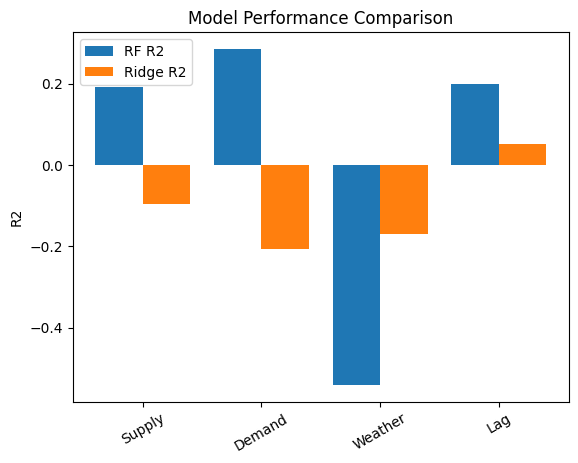

In [28]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
rf_r2 = [results[m]["rf_r2"] for m in model_names]
ridge_r2 = [results[m]["ridge_r2"] for m in model_names]
x = range(len(model_names))

plt.figure()
plt.bar(x, rf_r2, width=0.4, label="RF R2")
plt.bar([i + 0.4 for i in x], ridge_r2, width=0.4, label="Ridge R2")

plt.xticks([i + 0.2 for i in x], model_names, rotation=30)
plt.ylabel("R2")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

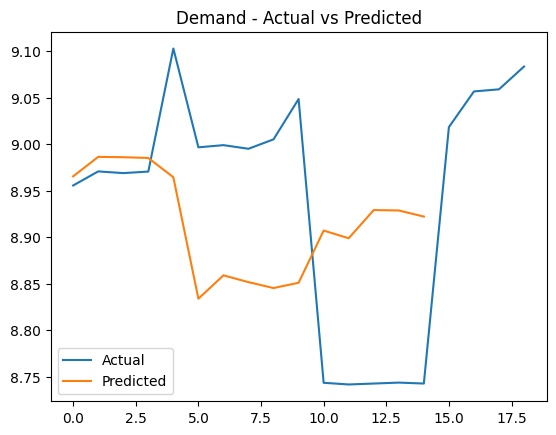

In [29]:
best_model = max(results, key=lambda x: results[x]["rf_r2"])

y_actual = master_model[TARGET].values
y_pred = results[best_model]["rf_preds"]

plt.figure()
plt.plot(y_actual, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title(f"{best_model} - Actual vs Predicted")
plt.legend()
plt.show()

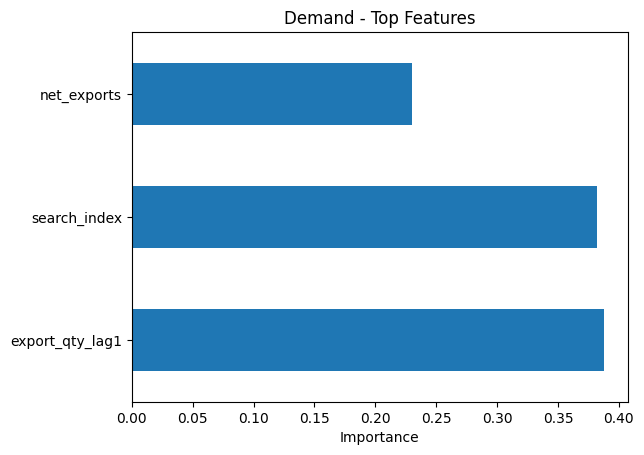

In [30]:
results[best_model]["rf_importance"].head(5).plot(kind="barh")
plt.title(f"{best_model} - Top Features")
plt.xlabel("Importance")
plt.show()